<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Homework_10_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

**Authors:**

- Richard (Yu) Liu: https://github.com/RichardLiuCoding

- Sergei V. Kalinin: https://github.com/SergeiVKalinin


**Gaussian Process Hackathon: Three Core Challenges**

This notebook is organized around **three main questions**:

1. **Get familiar with Gaussian processes through kernels and kernel length scale**
2. **Condition on data with different noise priors and non-Gaussian noise**
3. **Learn kernel length and noise from data using a heatmap, then extend it to active learning**

Each section includes:
- a short explanation
- guiding questions
- starter code
- example datasets
- space for your own exploration


# Helper functions and datasets

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional

plt.rcParams["figure.dpi"] = 120


## Example datasets

In [2]:
def true_func_smooth(x: np.ndarray) -> np.ndarray:
    return 0.8 * np.sin(1.2 * x) + 0.25 * np.cos(2.7 * x)

def true_func_rough(x: np.ndarray) -> np.ndarray:
    return 0.55 * np.sin(2.4 * x) + 0.25 * np.sin(6.0 * x + 0.4)

def true_func_periodic(x: np.ndarray) -> np.ndarray:
    return np.sin(2 * np.pi * x / 3.0)

def sample_bimodal_noise(rng: np.random.Generator, n: int,
                         sigma1: float = 0.08,
                         sigma2: float = 0.30,
                         p: float = 0.5) -> np.ndarray:
    choose = rng.uniform(size=n) < p
    noise = np.empty(n)
    noise[choose] = rng.normal(0.0, sigma1, size=choose.sum())
    noise[~choose] = rng.normal(0.0, sigma2, size=(~choose).sum())
    return noise

def sample_outlier_noise(rng: np.random.Generator, n: int,
                         sigma: float = 0.08,
                         outlier_prob: float = 0.10,
                         outlier_scale: float = 1.0) -> np.ndarray:
    noise = rng.normal(0.0, sigma, size=n)
    mask = rng.uniform(size=n) < outlier_prob
    noise[mask] += rng.normal(0.0, outlier_scale, size=mask.sum())
    return noise

def make_dataset(kind: str = "smooth_gaussian",
                 n_train: int = 18,
                 x_range: Tuple[float, float] = (-5.0, 5.0),
                 seed: int = 0):
    rng = np.random.default_rng(seed)
    x_train = np.linspace(x_range[0], x_range[1], n_train)

    if kind == "smooth_gaussian":
        f = true_func_smooth
        y_true = f(x_train)
        y = y_true + rng.normal(0.0, 0.12, size=n_train)
    elif kind == "rough_gaussian":
        f = true_func_rough
        y_true = f(x_train)
        y = y_true + rng.normal(0.0, 0.12, size=n_train)
    elif kind == "periodic_gaussian":
        f = true_func_periodic
        y_true = f(x_train)
        y = y_true + rng.normal(0.0, 0.10, size=n_train)
    elif kind == "smooth_bimodal":
        f = true_func_smooth
        y_true = f(x_train)
        y = y_true + sample_bimodal_noise(rng, n_train)
    elif kind == "smooth_outliers":
        f = true_func_smooth
        y_true = f(x_train)
        y = y_true + sample_outlier_noise(rng, n_train)
    else:
        raise ValueError(f"Unknown dataset kind: {kind}")

    x_test = np.linspace(x_range[0], x_range[1], 500)
    y_test_true = f(x_test)

    return {
        "x_train": x_train,
        "y_train": y,
        "y_train_true": y_true,
        "x_test": x_test,
        "y_test_true": y_test_true,
        "kind": kind,
    }


## Different kernels

In [3]:
def _pairwise_distances(X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
    X1 = np.asarray(X1).reshape(-1, 1)
    X2 = np.asarray(X2).reshape(-1, 1)
    return np.abs(X1 - X2.T)

def kernel_rbf(X1: np.ndarray, X2: np.ndarray,
               amplitude: float = 1.0,
               length: float = 1.0) -> np.ndarray:
    r = _pairwise_distances(X1, X2)
    return amplitude ** 2 * np.exp(-0.5 * (r / length) ** 2)

def kernel_matern12(X1: np.ndarray, X2: np.ndarray,
                    amplitude: float = 1.0,
                    length: float = 1.0) -> np.ndarray:
    r = _pairwise_distances(X1, X2)
    return amplitude ** 2 * np.exp(-r / length)

def kernel_matern32(X1: np.ndarray, X2: np.ndarray,
                    amplitude: float = 1.0,
                    length: float = 1.0) -> np.ndarray:
    r = _pairwise_distances(X1, X2)
    z = np.sqrt(3.0) * r / length
    return amplitude ** 2 * (1.0 + z) * np.exp(-z)

def kernel_matern52(X1: np.ndarray, X2: np.ndarray,
                    amplitude: float = 1.0,
                    length: float = 1.0) -> np.ndarray:
    r = _pairwise_distances(X1, X2)
    z = np.sqrt(5.0) * r / length
    return amplitude ** 2 * (1.0 + z + z ** 2 / 3.0) * np.exp(-z)

def kernel_periodic(X1: np.ndarray, X2: np.ndarray,
                    amplitude: float = 1.0,
                    length: float = 1.0,
                    period: float = 3.0) -> np.ndarray:
    r = _pairwise_distances(X1, X2)
    s = np.sin(np.pi * r / period)
    return amplitude ** 2 * np.exp(-2.0 * (s ** 2) / (length ** 2))


## GP regressor

In [4]:
@dataclass
class GaussianProcessRegressor1D:
    kernel: Callable
    kernel_params: Dict[str, float]
    noise: float = 1e-3
    jitter: float = 1e-8

    X_train: Optional[np.ndarray] = None
    y_train: Optional[np.ndarray] = None
    K: Optional[np.ndarray] = None
    alpha: Optional[np.ndarray] = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray) -> None:
        self.X_train = np.asarray(X_train).reshape(-1)
        self.y_train = np.asarray(y_train).reshape(-1)
        self.K = self.kernel(self.X_train, self.X_train, **self.kernel_params)
        self.K = self.K + (self.noise ** 2 + self.jitter) * np.eye(len(self.X_train))
        self.alpha = np.linalg.solve(self.K, self.y_train)

    def predict(self, X_test: np.ndarray, return_cov: bool = False):
        if self.X_train is None or self.alpha is None:
            raise RuntimeError("Call fit() before predict().")

        X_test = np.asarray(X_test).reshape(-1)
        Ks = self.kernel(self.X_train, X_test, **self.kernel_params)
        Kss = self.kernel(X_test, X_test, **self.kernel_params)
        Kss = Kss + self.jitter * np.eye(len(X_test))

        mu = Ks.T @ self.alpha
        v = np.linalg.solve(self.K, Ks)
        cov = Kss - Ks.T @ v
        var = np.clip(np.diag(cov), 0.0, None)

        if return_cov:
            return mu, cov
        return mu, var

    def sample_prior(self, X: np.ndarray, n_samples: int = 5, seed: int = 0):
        X = np.asarray(X).reshape(-1)
        K = self.kernel(X, X, **self.kernel_params)
        K = K + self.jitter * np.eye(len(X))
        rng = np.random.default_rng(seed)
        return rng.multivariate_normal(mean=np.zeros(len(X)), cov=K, size=n_samples)

    def negative_log_marginal_likelihood(self) -> float:
        if self.X_train is None or self.y_train is None or self.K is None:
            raise RuntimeError("Call fit() before evaluating NLML.")
        sign, logdet = np.linalg.slogdet(self.K)
        if sign <= 0:
            return np.inf
        n = len(self.y_train)
        data_fit = 0.5 * self.y_train @ self.alpha
        complexity = 0.5 * logdet
        constant = 0.5 * n * np.log(2 * np.pi)
        return float(data_fit + complexity + constant)


## plotting utilities

In [5]:
def plot_covariance_matrix(K: np.ndarray, title: str = "Covariance matrix"):
    plt.figure(figsize=(5, 4))
    plt.imshow(K, origin="lower", aspect="auto")
    plt.colorbar(label="covariance")
    plt.title(title)
    plt.xlabel("index")
    plt.ylabel("index")
    plt.tight_layout()
    plt.show()

def plot_prior_samples(X: np.ndarray, samples: np.ndarray, title: str = "GP prior samples"):
    plt.figure(figsize=(7, 4))
    for s in samples:
        plt.plot(X, s)
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_posterior(X_train, y_train, X_test, mu, var, y_true=None, title="GP posterior"):
    std = np.sqrt(np.maximum(var, 0.0))
    plt.figure(figsize=(7, 4))
    if y_true is not None:
        plt.plot(X_test, y_true, "--", label="True function")
    plt.scatter(X_train, y_train, s=45, label="Observed data", zorder=3)
    plt.plot(X_test, mu, label="Predictive mean")
    plt.fill_between(X_test, mu - 2 * std, mu + 2 * std, alpha=0.25, label="±2σ")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Task - 1: Get familiar with Gaussian processes

Build intuition for how the GP prior and posterior change when you vary the kernel choice and kernel length scale.

**Tasks:**

* Construct GP models using at least these kernels:
  - RBF
  - Matérn 1/2
  - Matérn 3/2
  - Matérn 5/2
  - Periodic

* For each kernel, draw several samples from the GP prior.
* For each kernel, plot the covariance matrix as a heatmap.
* Choose one kernel family, such as RBF, and vary the kernel length scale over a range from small to large values.
* For each length scale, plot:
  - prior samples
  - posterior prediction after conditioning on a small training dataset
  - predictive uncertainty band (fill between uncertainties)

**Problem-1:**

* What kinds of functions are favored by each kernel?
* Which kernel produces the smoothest prior samples?
* Which kernel produces the roughest prior samples?
* Which kernel is most suitable for periodic structure?
* What happens when the kernel length scale is very small?
* What happens when the kernel length scale is very large?
* How does the kernel length scale change the correlation between nearby and distant points?
* How does uncertainty change in regions far from the observed data?

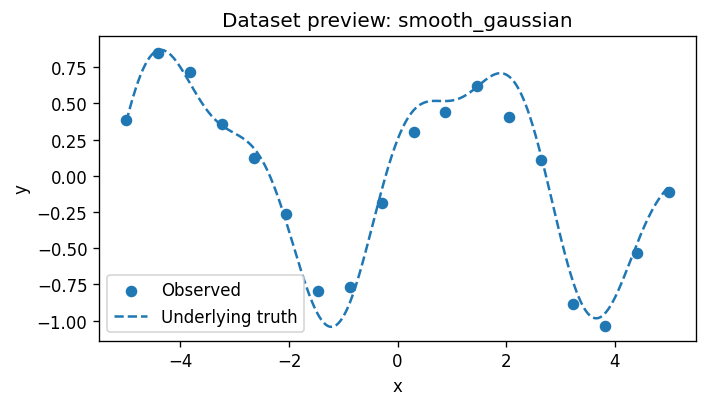

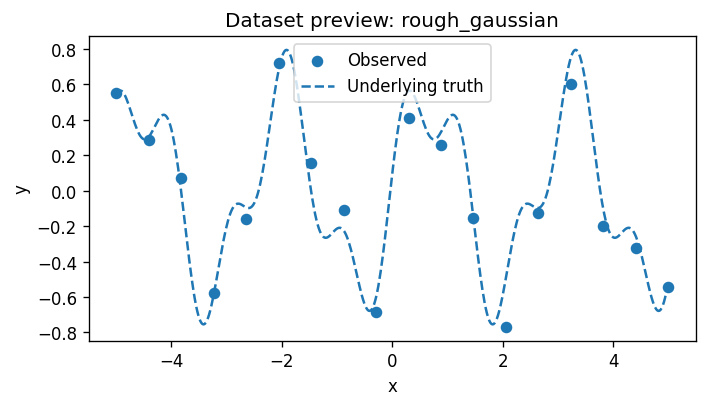

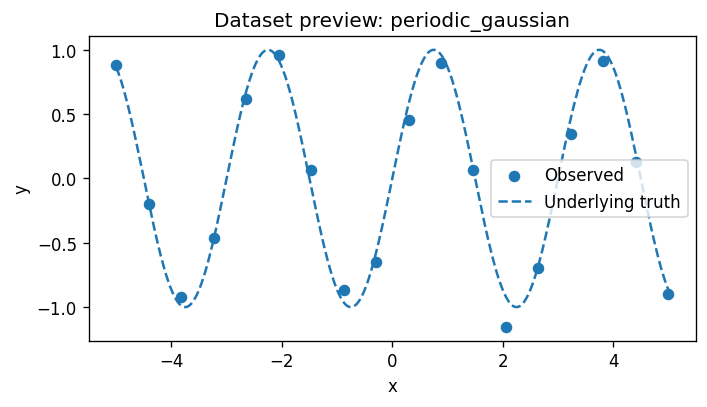

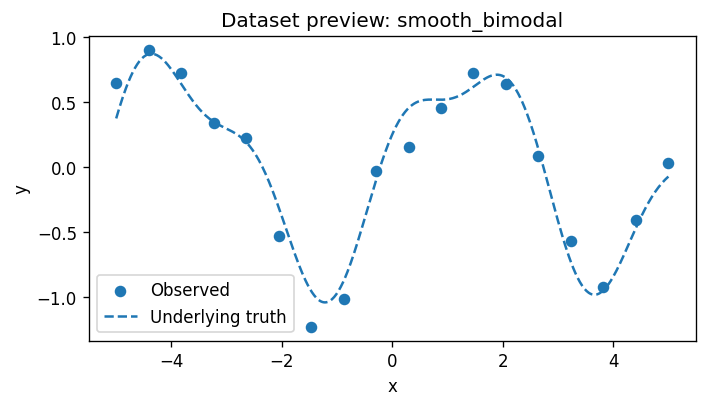

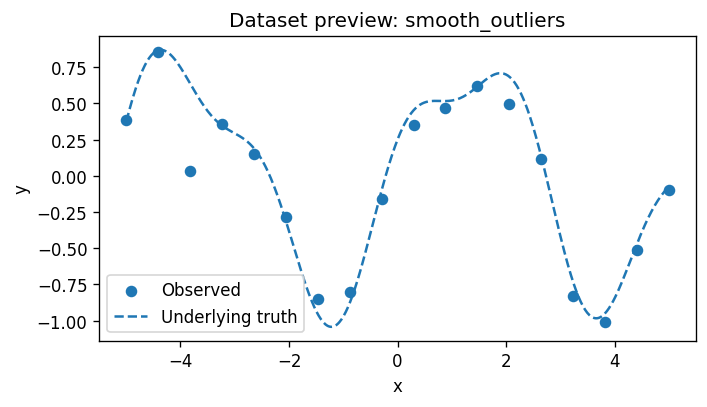

In [6]:
# Here are some example datasets with noise:

dataset_kinds = [
    "smooth_gaussian",
    "rough_gaussian",
    "periodic_gaussian",
    "smooth_bimodal",
    "smooth_outliers",
]

for kind in dataset_kinds:
    ds = make_dataset(kind, seed=0)
    plt.figure(figsize=(6, 3.5))
    plt.scatter(ds["x_train"], ds["y_train"], s=35, label="Observed")
    plt.plot(ds["x_test"], ds["y_test_true"], "--", label="Underlying truth")
    plt.title(f"Dataset preview: {kind}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [7]:
# This is an exmaple implementation for the RBF kernel

def student_rbf_kernel(X1: np.ndarray, X2: np.ndarray,
                       amplitude: float = 1.0,
                       length: float = 1.0) -> np.ndarray:
    # Implement the RBF kernel:
    # k(x, x') = amplitude^2 * exp(-(x-x')^2 / (2*length^2))
    X1 = np.atleast_2d(X1).reshape(-1, 1)
    X2 = np.atleast_2d(X2).reshape(-1, 1)
    sqdist = (X1 - X2.T) ** 2
    return amplitude ** 2 * np.exp(-0.5 * sqdist / (length ** 2))

def student_gp_posterior(X_train: np.ndarray,
                         y_train: np.ndarray,
                         X_test: np.ndarray,
                         kernel_fn: Callable,
                         noise: float = 1e-6,
                         jitter: float = 1e-8):
    K = kernel_fn(X_train, X_train) + (noise ** 2 + jitter) * np.eye(len(X_train))
    Ks = kernel_fn(X_train, X_test)
    Kss = kernel_fn(X_test, X_test) + jitter * np.eye(len(X_test))

    alpha = np.linalg.solve(K, y_train)
    mu_test = Ks.T @ alpha
    v = np.linalg.solve(K, Ks)
    cov_test = Kss - Ks.T @ v
    return mu_test, cov_test

def student_plot_prediction(X_train, y_train, X_test, mu, var, y_true=None, title=""):
    std = np.sqrt(np.maximum(var, 0.0))
    plt.figure(figsize=(7, 4))
    if y_true is not None:
        plt.plot(X_test, y_true, "--", label="True function")
    plt.scatter(X_train, y_train, s=40, label="Train data", zorder=3)
    plt.plot(X_test, mu, label="Predictive mean")
    plt.fill_between(X_test, mu - 2 * std, mu + 2 * std, alpha=0.25, label="±2σ")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()


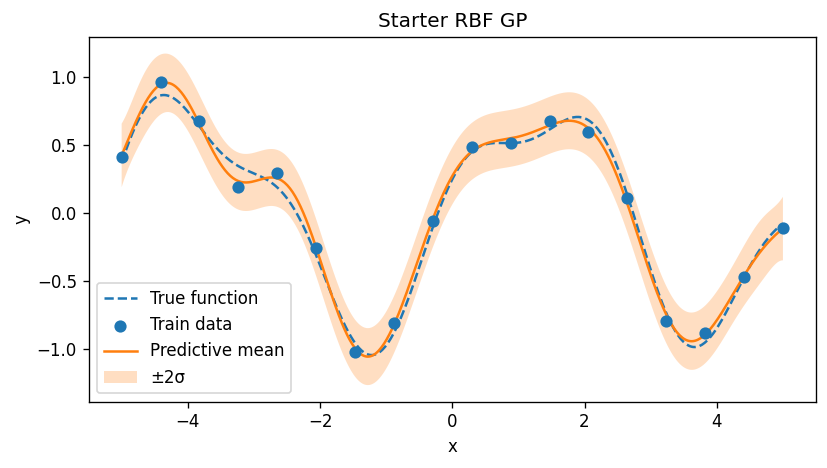

In [8]:
# and how it's fitted to the data

ds = make_dataset("smooth_gaussian", seed=1)
mu, cov = student_gp_posterior(
    ds["x_train"],
    ds["y_train"],
    ds["x_test"],
    lambda a, b: student_rbf_kernel(a, b, amplitude=1.0, length=0.8),
    noise=0.12,
)
student_plot_prediction(
    ds["x_train"], ds["y_train"], ds["x_test"],
    mu, np.diag(cov), y_true=ds["y_test_true"],
    title="Starter RBF GP"
)
plt.show()


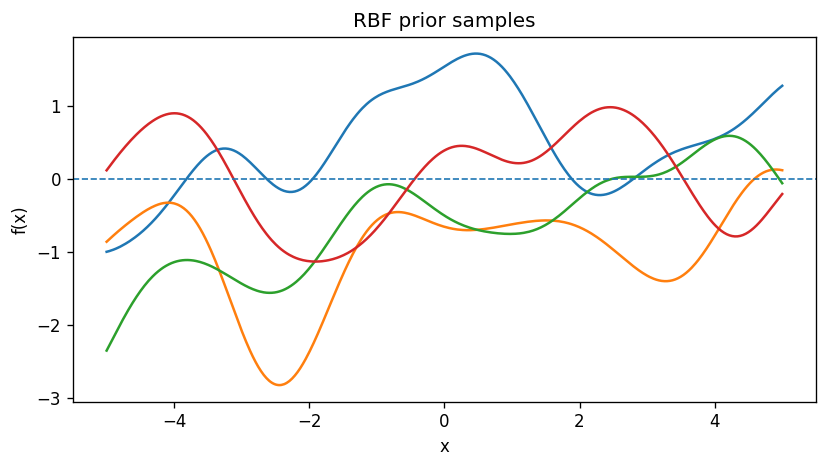

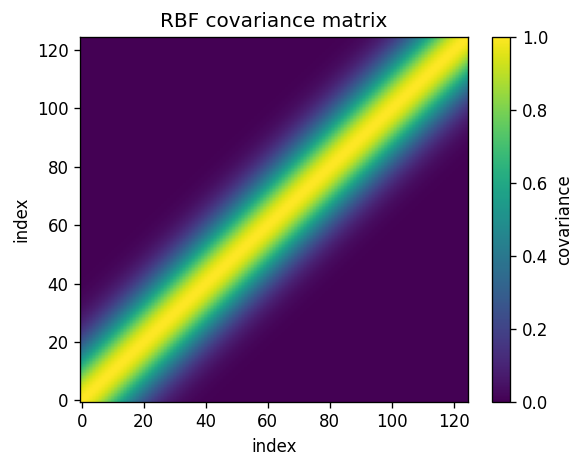

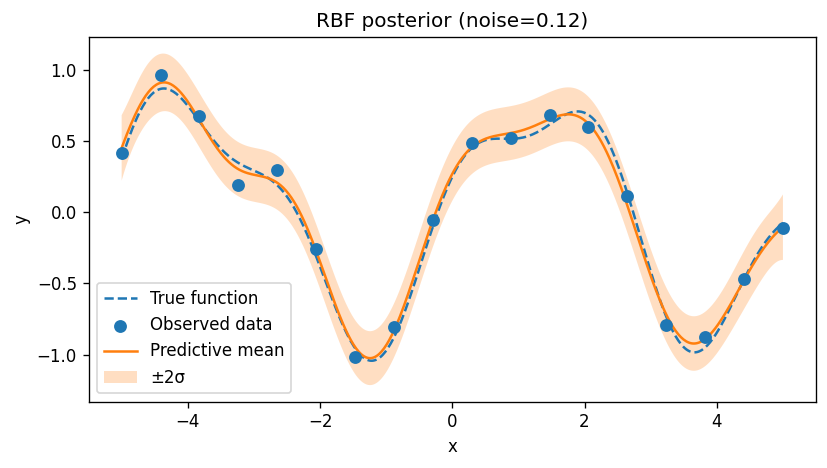

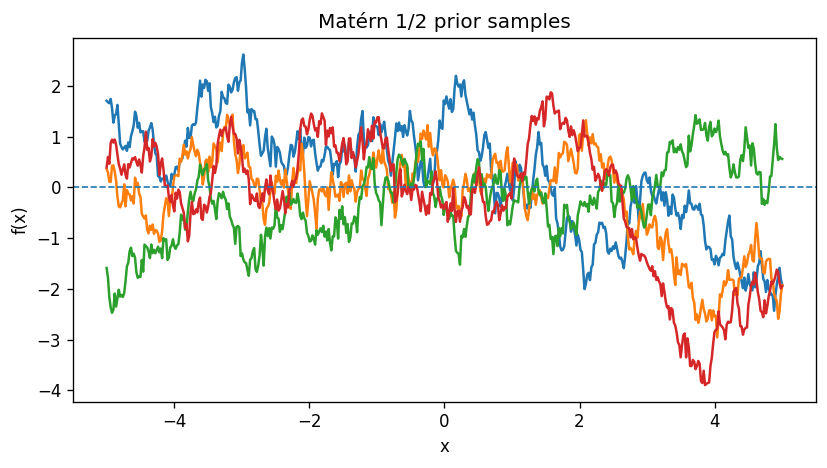

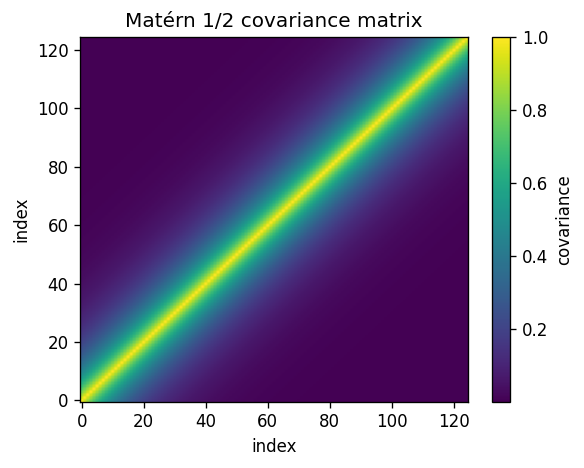

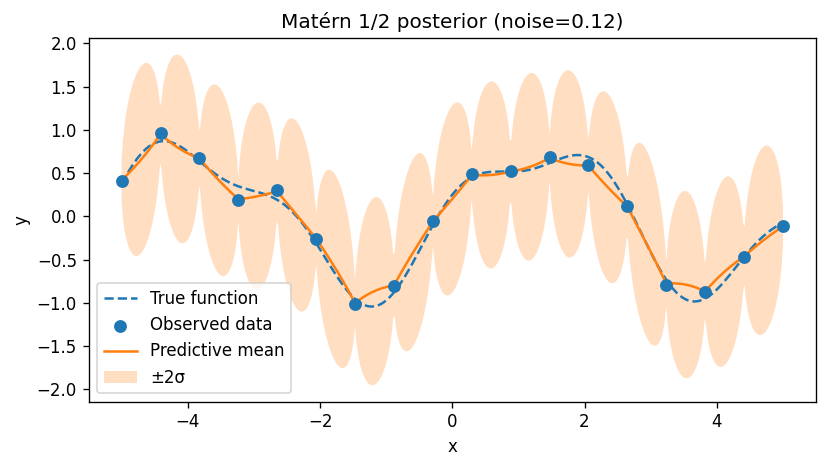

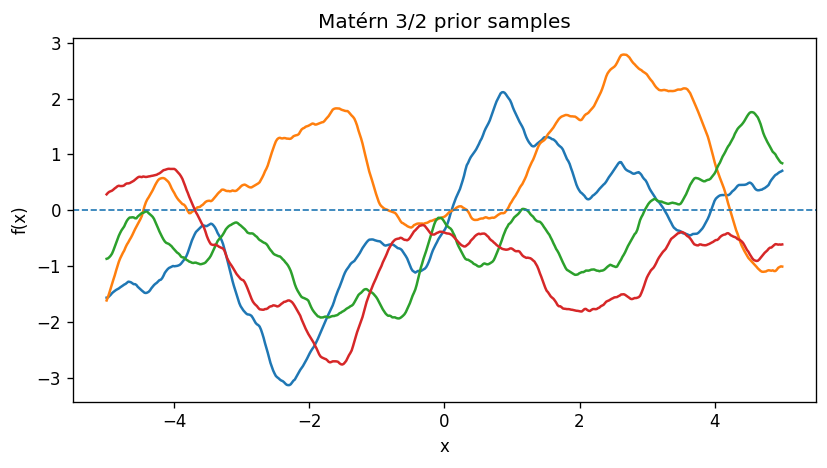

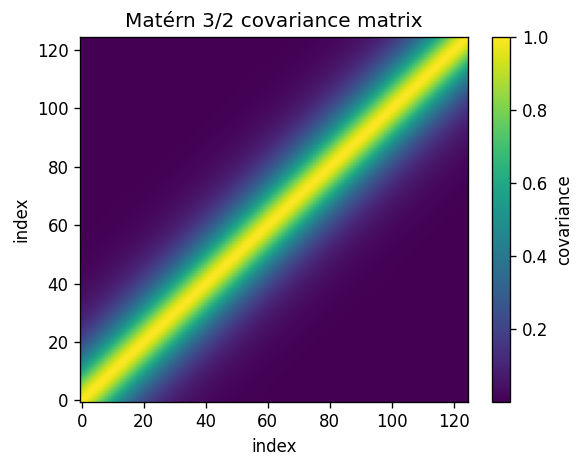

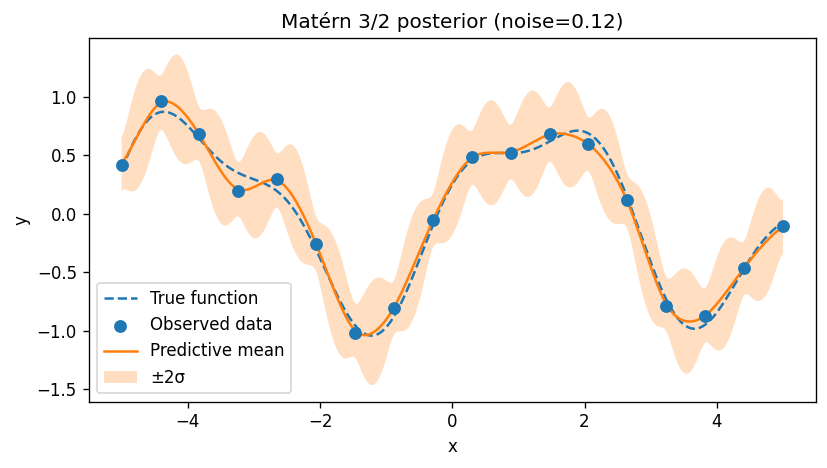

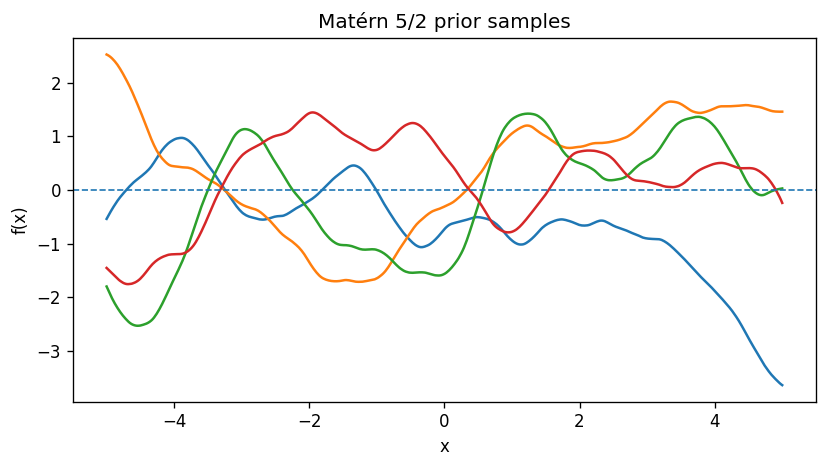

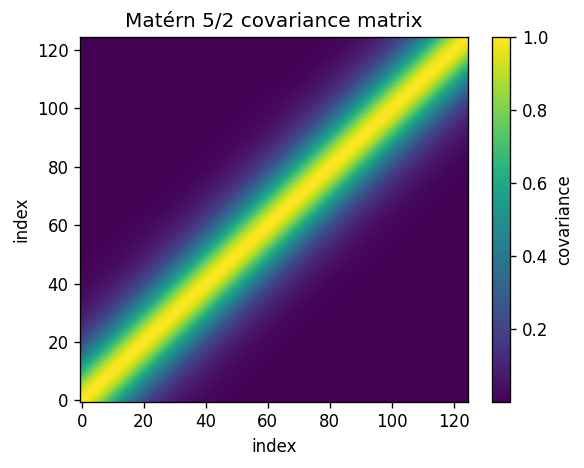

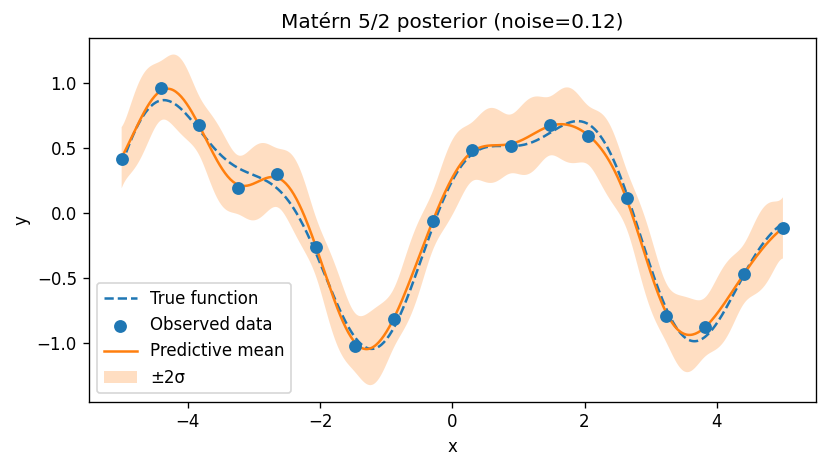

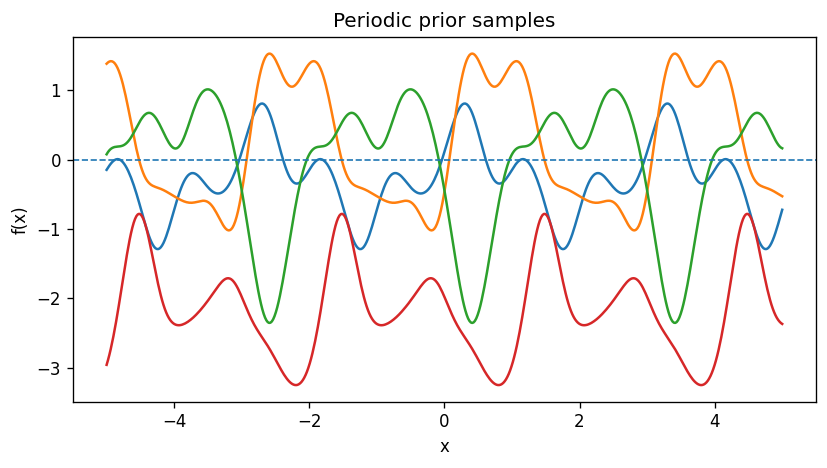

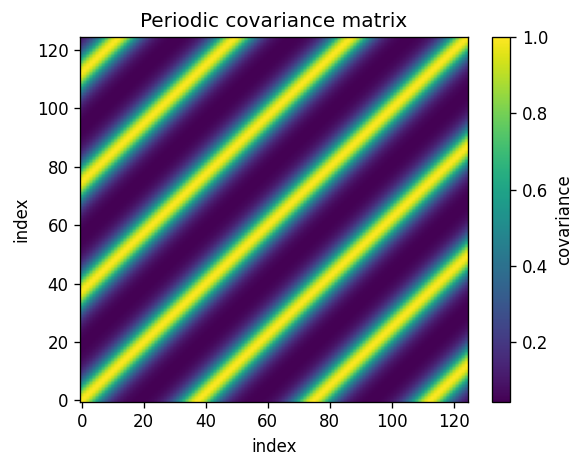

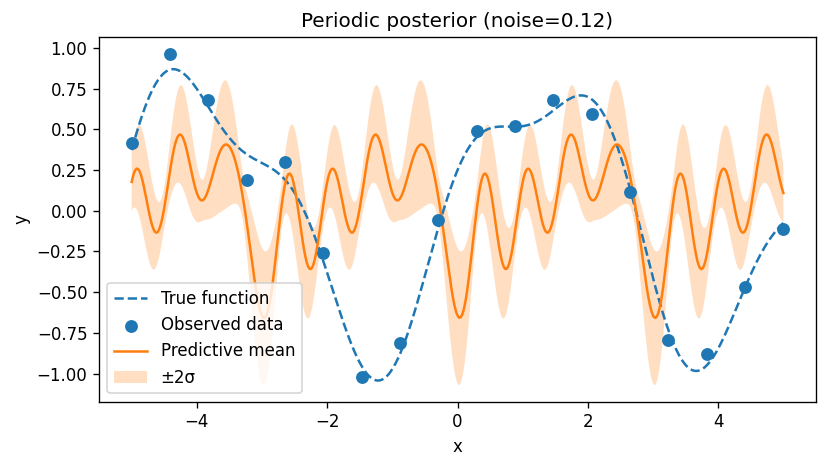

In [9]:
ds = make_dataset("smooth_gaussian", seed=1)
xtr, ytr = ds["x_train"], ds["y_train"]
xte, ytrue = ds["x_test"], ds["y_test_true"]

kernels = [
    ("RBF", kernel_rbf, dict(amplitude=1.0, length=1.0)),
    ("Matérn 1/2", kernel_matern12, dict(amplitude=1.0, length=1.0)),
    ("Matérn 3/2", kernel_matern32, dict(amplitude=1.0, length=1.0)),
    ("Matérn 5/2", kernel_matern52, dict(amplitude=1.0, length=1.0)),
    ("Periodic", kernel_periodic, dict(amplitude=1.0, length=0.8, period=3.0)),
]

# Student task:
# 1. Loop over kernels
# 2. Draw prior samples
# 3. Plot covariance matrix
# 4. Fit posterior and plot mean ± 2 sigma

for i, (name, kernel_fn, params) in enumerate(kernels):
    gp = GaussianProcessRegressor1D(kernel=kernel_fn, kernel_params=params, noise=0.12)

    prior_samples = gp.sample_prior(xte, n_samples=4, seed=100 + i)
    plot_prior_samples(xte, prior_samples, title=f"{name} prior samples")

    K = kernel_fn(xte[::4], xte[::4], **params)
    plot_covariance_matrix(K, title=f"{name} covariance matrix")

    gp.fit(xtr, ytr)
    mu, var = gp.predict(xte)
    plot_posterior(
        xtr,
        ytr,
        xte,
        mu,
        var,
        y_true=ytrue,
        title=f"{name} posterior (noise=0.12)",
    )


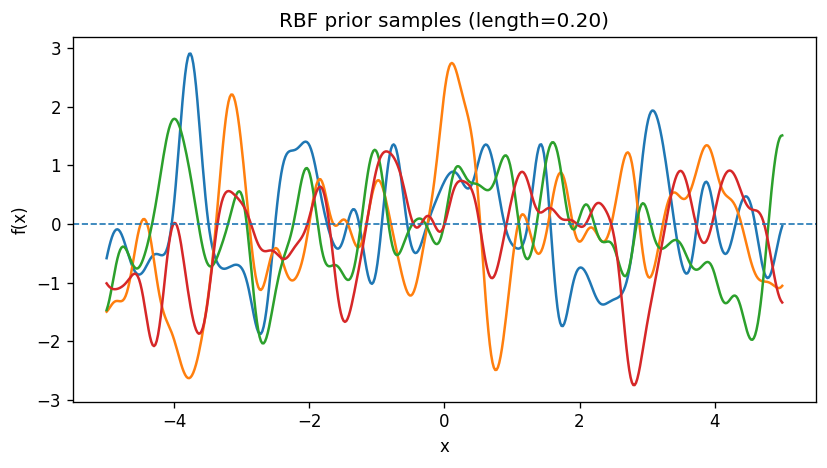

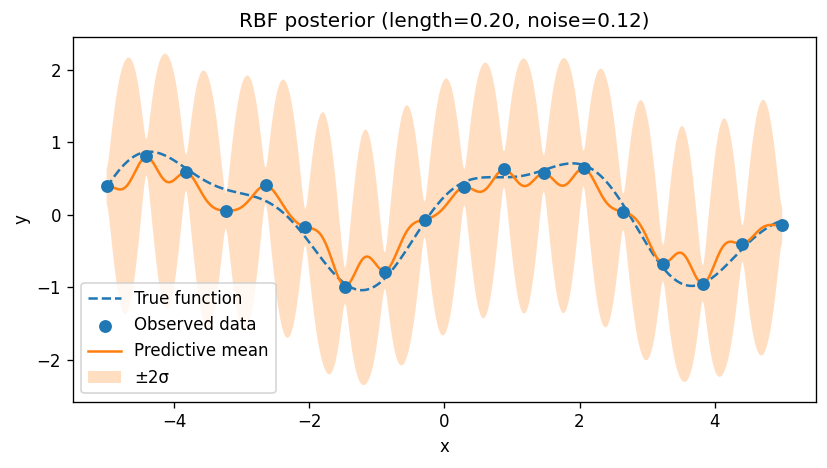

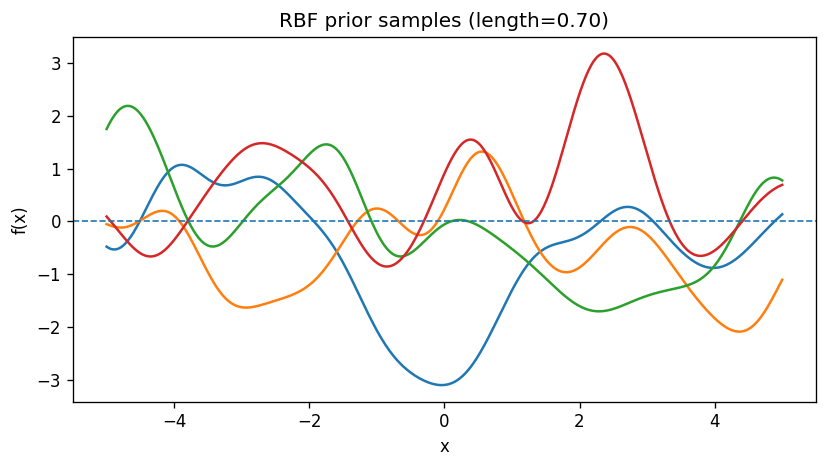

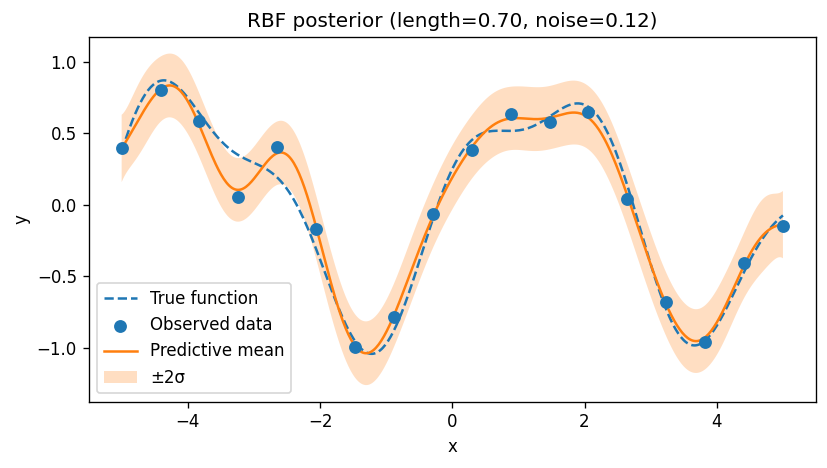

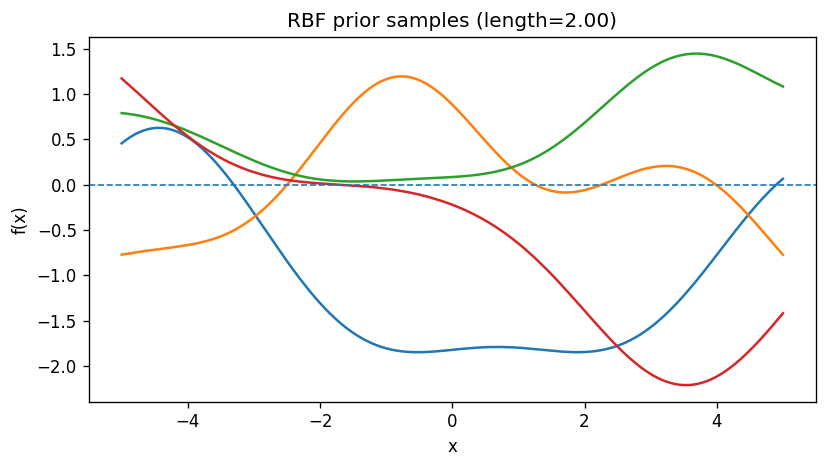

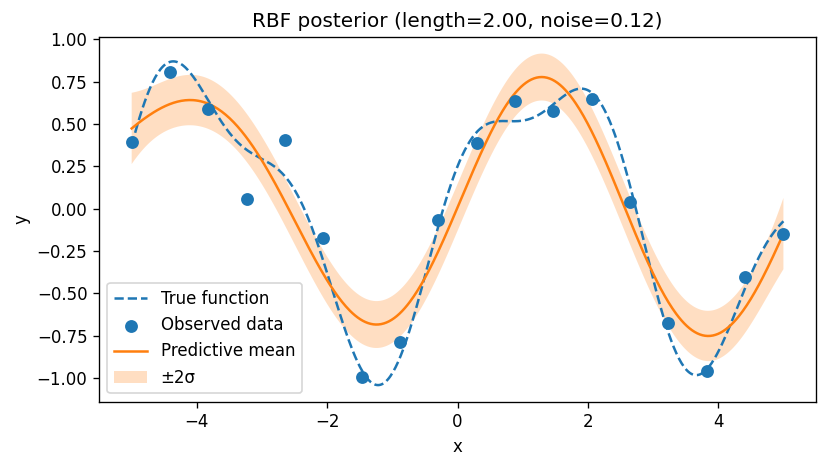

In [10]:
lengths = [0.2, 0.7, 2.0]

# Student task:
# Use one kernel family, vary the length scale, and compare prior/posterior behavior.


ds = make_dataset("smooth_gaussian", seed=2)
xtr, ytr = ds["x_train"], ds["y_train"]
xte, ytrue = ds["x_test"], ds["y_test_true"]

for i, ell in enumerate(lengths):
    params = dict(amplitude=1.0, length=float(ell))
    gp = GaussianProcessRegressor1D(kernel=kernel_rbf, kernel_params=params, noise=0.12)

    prior = gp.sample_prior(xte, n_samples=4, seed=200 + i)
    plot_prior_samples(xte, prior, title=f"RBF prior samples (length={ell:.2f})")

    gp.fit(xtr, ytr)
    mu, var = gp.predict(xte)
    plot_posterior(
        xtr,
        ytr,
        xte,
        mu,
        var,
        y_true=ytrue,
        title=f"RBF posterior (length={ell:.2f}, noise=0.12)",
    )


**Answers to Problem-1:**

- **What kinds of functions are favored by each kernel?**  
  - **RBF kernel:** favors very smooth and slowly varying functions.  
  - **Matérn 1/2 kernel:** favors rough, jagged, and less smooth functions.  
  - **Matérn 3/2 kernel:** favors moderately smooth functions.  
  - **Matérn 5/2 kernel:** favors fairly smooth functions, smoother than Matérn 3/2 but less smooth than RBF.  
  - **Periodic kernel:** favors repeating, wave-like functions with a fixed period.  

- **Which kernel produces the smoothest prior samples?**  
  - The **RBF kernel** produces the smoothest prior samples.  

- **Which kernel produces the roughest prior samples?**  
  - The **Matérn 1/2 kernel** produces the roughest prior samples.  

- **Which kernel is most suitable for periodic structure?**  
  - The **Periodic kernel** is the most suitable for periodic structure.  

- **What happens when the kernel length scale is very small?**  
  - The function changes very quickly over short distances.  


- **What happens when the kernel length scale is very large?**  
  - The function changes slowly over distance.  


- **How does the kernel length scale change the correlation between nearby and distant points?**  
  - With a **small length scale**, correlation drops off quickly, so only nearby points strongly influence each other.  


- **How does uncertainty change in regions far from the observed data?**  
  - Uncertainty **increases far from the observed data** because the model has less information in those regions.  

# Task - 2: Condition on data with different noise priors and noise models

**Tasks**
* Start from the same training dataset and fit
* GP models under these cases:
  - zero noise
  - small Gaussian noise
  - moderate Gaussian noise
  - large Gaussian noise
* Then treat the noise level as an unknown hyperparameter and explore several different noise priors or preferences, for example:
  - prior favoring very small noise
  - broad prior over noise
  - prior favoring larger noise
* Generate an additional dataset with non-Gaussian noise, such as:
bimodal noise from a mixture of two Gaussians
outlier-contaminated noise
* Fit this non-Gaussian dataset using a standard GP with Gaussian noise assumption.
* For every case above, plot:
  - training data
  - GP predictive mean
  - predictive uncertainty band, such as mean ± 2σ

**Problem-2:**

* In the zero-noise case, does the GP interpolate the data exactly?
* How does increasing Gaussian noise change the posterior mean?
* How does increasing Gaussian noise change the predictive uncertainty?
* Which regions of the input space are most sensitive to the noise assumption?
* How do different noise priors change the inferred posterior and uncertainty?
* When the true noise is non-Gaussian, what mismatch do you observe in the GP fit?
* Does the uncertainty band remain trustworthy under non-Gaussian noise?
* What kinds of models or likelihoods might better handle bimodal noise or outliers?


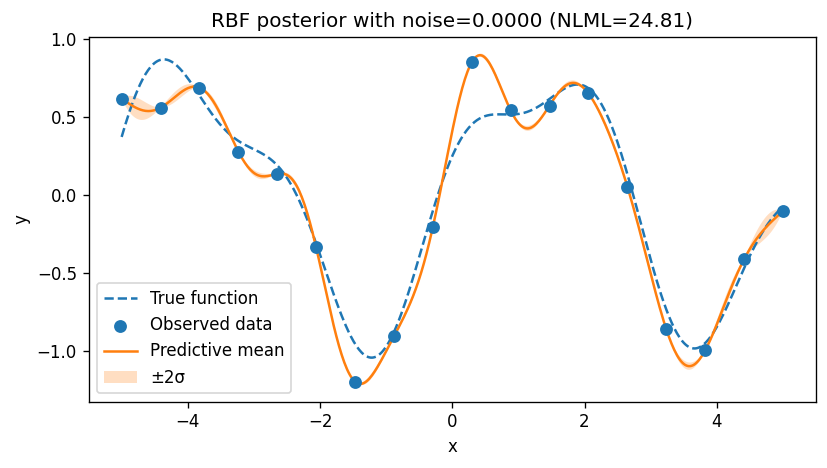

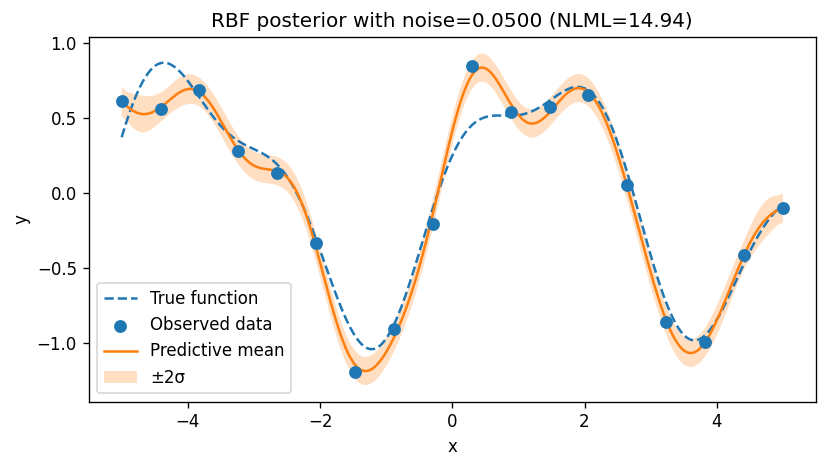

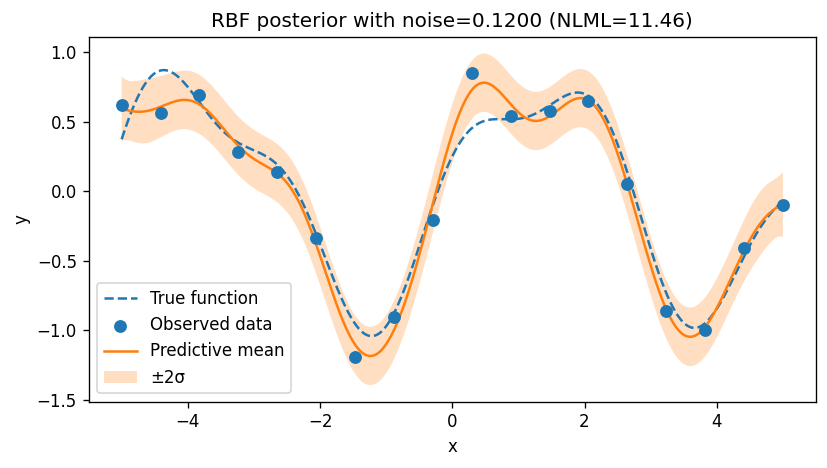

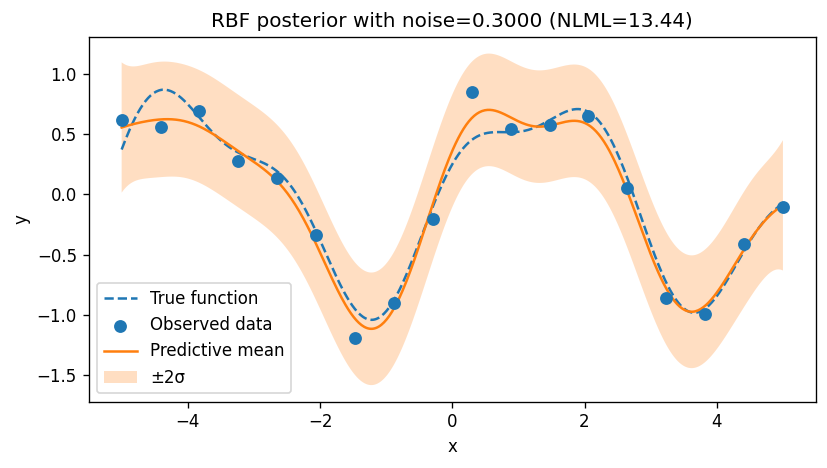

In [11]:
ds = make_dataset("smooth_gaussian", seed=3)
xtr, ytr = ds["x_train"], ds["y_train"]
xte, ytrue = ds["x_test"], ds["y_test_true"]

noise_values = [1e-6, 0.05, 0.12, 0.30]

# Student task:
# Fit the same dataset using each noise value and compare the predictive mean and uncertainty.


for noise in noise_values:
    gp = GaussianProcessRegressor1D(
        kernel=kernel_rbf,
        kernel_params=dict(amplitude=1.0, length=0.8),
        noise=float(noise),
    )
    gp.fit(xtr, ytr)
    mu, var = gp.predict(xte)
    nlml = gp.negative_log_marginal_likelihood()

    plot_posterior(
        xtr,
        ytr,
        xte,
        mu,
        var,
        y_true=ytrue,
        title=f"RBF posterior with noise={noise:.4f} (NLML={nlml:.2f})",
    )


small-noise prior  -> best noise=0.0800, NLML=12.428
broad prior        -> best noise=0.1352, NLML=11.406
large-noise prior  -> best noise=0.1333, NLML=11.407


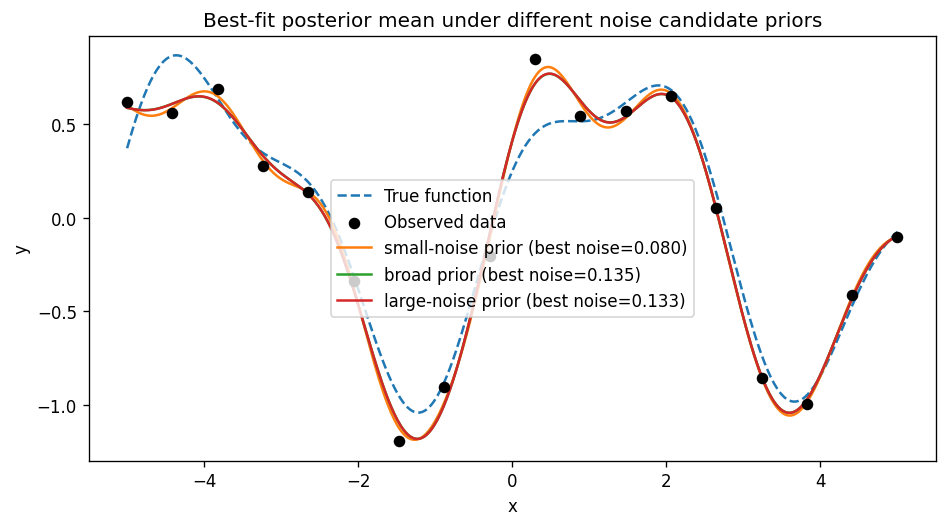

In [12]:
def best_noise_from_candidates(X_train, y_train, X_test, kernel_fn, kernel_params, noise_candidates):
    best_gp = None
    best_score = np.inf
    best_noise = None

    for noise in noise_candidates:
        gp = GaussianProcessRegressor1D(kernel=kernel_fn, kernel_params=kernel_params, noise=float(noise))
        gp.fit(X_train, y_train)
        score = gp.negative_log_marginal_likelihood()
        if score < best_score:
            best_score = score
            best_gp = gp
            best_noise = noise

    mu, var = best_gp.predict(X_test)
    return best_noise, mu, var, best_score

noise_prior_sets = {
    "small-noise prior": np.linspace(0.001, 0.08, 20),
    "broad prior": np.linspace(0.001, 0.35, 40),
    "large-noise prior": np.linspace(0.10, 0.50, 25),
}

# Student task:
# Compare best fits when the candidate noise range is small, broad, or large.


ds = make_dataset("smooth_gaussian", seed=3)
xtr, ytr = ds["x_train"], ds["y_train"]
xte, ytrue = ds["x_test"], ds["y_test_true"]

kernel_fn = kernel_rbf
kernel_params = dict(amplitude=1.0, length=0.8)

plt.figure(figsize=(8, 4.5))
plt.plot(xte, ytrue, "--", label="True function")
plt.scatter(xtr, ytr, s=35, c="k", label="Observed data", zorder=3)

for label, candidates in noise_prior_sets.items():
    best_noise, mu, var, best_score = best_noise_from_candidates(
        xtr, ytr, xte, kernel_fn, kernel_params, candidates
    )
    print(f"{label:18s} -> best noise={best_noise:.4f}, NLML={best_score:.3f}")
    plt.plot(xte, mu, label=f"{label} (best noise={best_noise:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Best-fit posterior mean under different noise candidate priors")
plt.legend()
plt.tight_layout()
plt.show()

- **In the zero-noise case, does the GP interpolate the data exactly?**  
  - Yes. In the zero-noise case (`noise = 1e-6`), the GP essentially interpolates the training data, so the posterior mean passes almost exactly through the observed points.

- **How does increasing Gaussian noise change the posterior mean?**  
  - With small noise, the fit closely follows the data. With large noise, the fit becomes more conservative and tracks the overall trend instead of every fluctuation.

- **How does increasing Gaussian noise change the predictive uncertainty?**  
  - Increasing Gaussian noise makes the predictive uncertainty band wider.  

- **Which regions of the input space are most sensitive to the noise assumption?**  
  - The regions near the observed training points are the most sensitive to the noise assumption.  

- **How do different noise priors change the inferred posterior and uncertainty?**  
  - Different noise priors restrict which noise values the model is allowed to prefer.  
  - In the notebook output:  
    - **small-noise prior** gave best noise about **0.0800**  
    - **broad prior** gave best noise about **0.1352**  
    - **large-noise prior** gave best noise about **0.1333**  
  - So the small-noise prior forces a tighter, more data-following fit, while the broad and large-noise priors lead to a smoother posterior mean and typically larger uncertainty.

- **When the true noise is non-Gaussian, what mismatch do you observe in the GP fit?**  
  - A standard GP with Gaussian noise would tend to average over the unusual points and may fit poorly around outliers or mixed-noise regions.  
  - The mean can be pulled in the wrong direction, and the fit may not represent the true data-generating pattern well.

- **Does the uncertainty band remain trustworthy under non-Gaussian noise?**  
  - If the true noise is non-Gaussian, the Gaussian likelihood assumption is mismatched.  


- **What kinds of models or likelihoods might better handle bimodal noise or outliers?**  
  - Better choices would include:  
    - **Student-t likelihood**, which is more robust to outliers  
    - **mixture likelihoods**, which can model bimodal noise  

# Task-3: Learn kernel length and noise through a heatmap, then turn it into active learning

Use data to infer the most likely kernel length scale and noise level, then update this estimate as new points are acquired sequentially.

**Tasks**
* Assume the kernel family is fixed, for example RBF, but the kernel length scale and noise level are unknown.
* Given an initial dataset, define a 2D grid over:
  - kernel length scale
  - noise level
* At each grid point, compute an objective such as the negative log marginal likelihood.
* Plot the 2D heatmap and identify the minimum.
* Interpret this minimum as the learned or most likely combination of kernel length and noise supported by the data.

**Active learning extension**
* Start from a small initial training set.
* Fit the GP and compute the heatmap over kernel length and noise.
* Use an acquisition rule to choose the next point to measure, for example:
  - largest predictive uncertainty
  - largest posterior variance
  - expected improvement, if you define an optimization target
* Add the new point to the dataset and recompute the heatmap.
* Repeat for several iterations.

**Problem-3:**

* Where is the minimum of the heatmap?
* Does the minimum match the true generating values reasonably well?
* Is the optimum sharp or broad?
* Is there a tradeoff ridge between kernel length and noise?
* As more data are added, does the heatmap minimum become more localized?
* Does active learning recover the correct hyperparameters faster than random sampling?
* How does the GP uncertainty evolve during the active learning loop?
* Which acquisition strategy seems most effective for identifying the correct kernel length and noise?

In [13]:
def compute_nlml_grid(X_train: np.ndarray,
                      y_train: np.ndarray,
                      kernel_fn: Callable,
                      amplitude: float,
                      length_grid: np.ndarray,
                      noise_grid: np.ndarray) -> np.ndarray:
    grid = np.empty((len(noise_grid), len(length_grid)))
    for i, noise in enumerate(noise_grid):
        for j, ell in enumerate(length_grid):
            gp = GaussianProcessRegressor1D(
                kernel=kernel_fn,
                kernel_params=dict(amplitude=amplitude, length=ell),
                noise=float(noise),
            )
            gp.fit(X_train, y_train)
            grid[i, j] = gp.negative_log_marginal_likelihood()
    return grid

def plot_nlml_heatmap(length_grid, noise_grid, nlml_grid,
                      title="Negative log marginal likelihood heatmap"):
    idx = np.unravel_index(np.argmin(nlml_grid), nlml_grid.shape)
    best_noise = noise_grid[idx[0]]
    best_length = length_grid[idx[1]]
    best_val = nlml_grid[idx]

    plt.figure(figsize=(7, 5))
    extent = [length_grid.min(), length_grid.max(), noise_grid.min(), noise_grid.max()]
    plt.imshow(nlml_grid, origin="lower", aspect="auto", extent=extent)
    plt.colorbar(label="NLML")
    plt.scatter([best_length], [best_noise], s=80, marker="x", label="Minimum")
    plt.xlabel("Kernel length scale")
    plt.ylabel("Noise level")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return best_length, best_noise, best_val


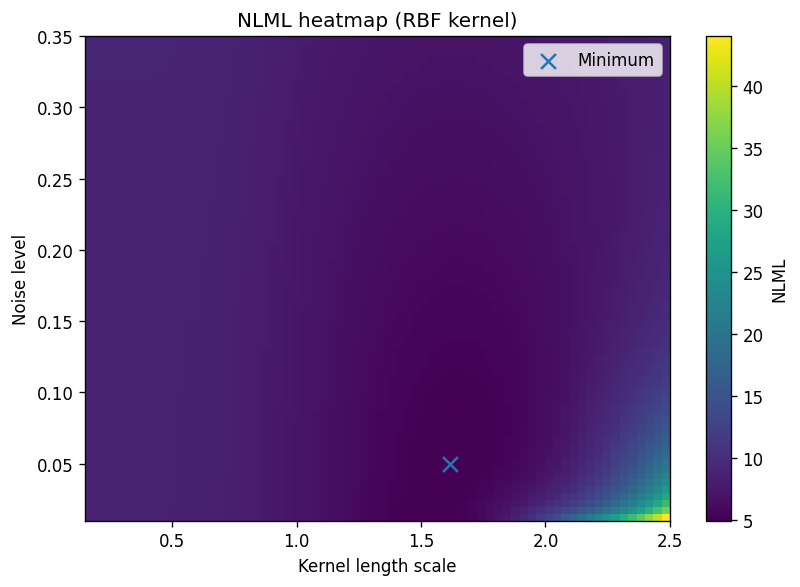

Best length scale: 1.6145
Best noise level:   0.0494
Minimum NLML:      4.9582


In [14]:
rng = np.random.default_rng(10)
X_train = np.linspace(-4.0, 4.0, 8)
y_true = true_func_smooth(X_train)
y_train = y_true + rng.normal(0.0, 0.10, size=len(X_train))

length_grid = np.linspace(0.15, 2.5, 70)
noise_grid = np.linspace(0.01, 0.35, 70)

# Student task:
# 1. Compute the NLML heatmap
# 2. Plot it
# 3. Identify the best length scale and noise

nlml_grid = compute_nlml_grid(
    X_train=X_train,
    y_train=y_train,
    kernel_fn=kernel_rbf,
    amplitude=1.0,
    length_grid=length_grid,
    noise_grid=noise_grid,
)

best_length, best_noise, best_val = plot_nlml_heatmap(
    length_grid,
    noise_grid,
    nlml_grid,
    title="NLML heatmap (RBF kernel)",
)

print(f"Best length scale: {best_length:.4f}")
print(f"Best noise level:   {best_noise:.4f}")
print(f"Minimum NLML:      {best_val:.4f}")

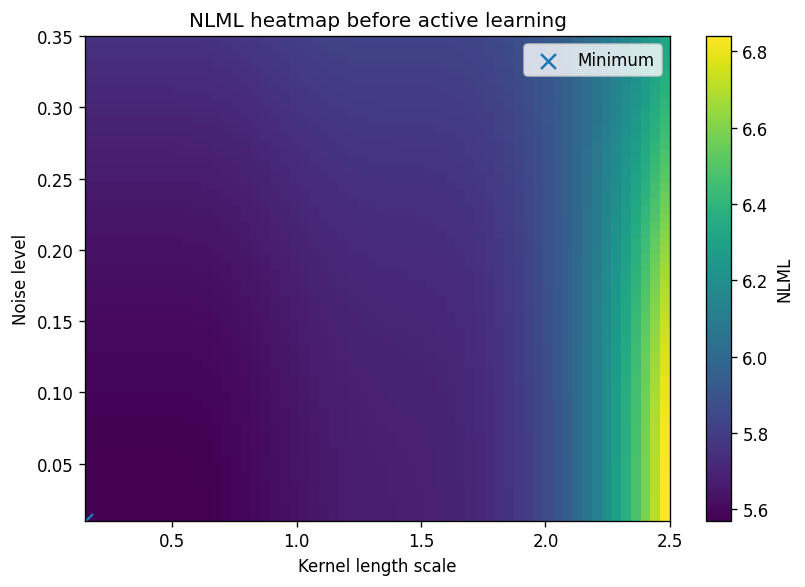

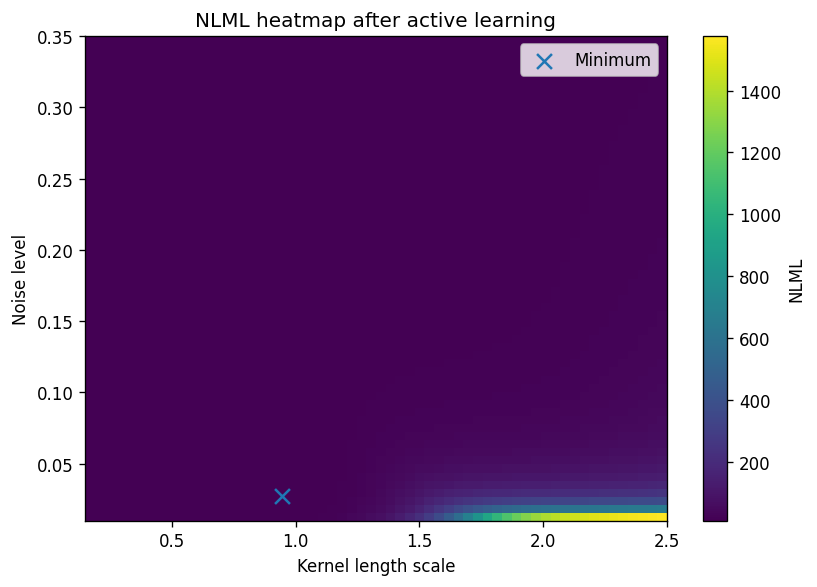

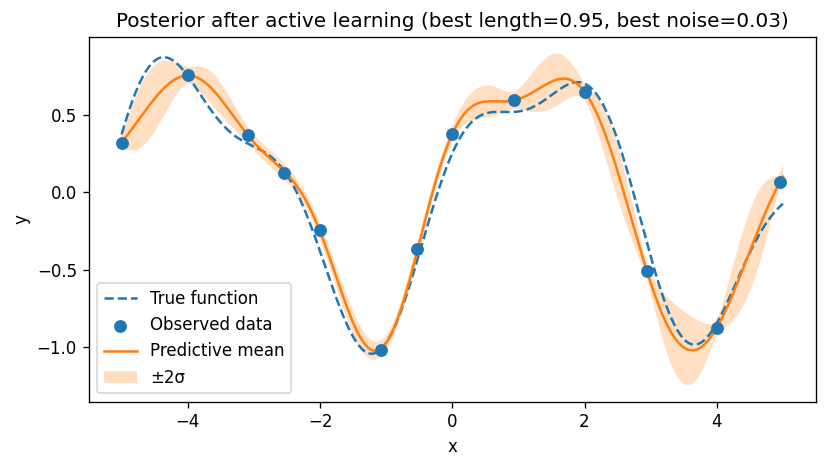

Selected points by max uncertainty:
Round 01: x=-5.000, predictive variance=1.0000
Round 02: x=-3.090, predictive variance=1.0000
Round 03: x=-1.080, predictive variance=1.0000
Round 04: x=+0.930, predictive variance=1.0000
Round 05: x=+2.940, predictive variance=1.0000
Round 06: x=+4.950, predictive variance=1.0000
Round 07: x=-2.538, predictive variance=1.0000
Round 08: x=-0.528, predictive variance=1.0000


In [15]:
def choose_next_point_by_uncertainty(X_pool, gp):
    mu, var = gp.predict(X_pool)
    idx = np.argmax(var)
    return idx, X_pool[idx], mu, var

def oracle(x):
    x = np.asarray(x)
    return true_func_smooth(x)

rng = np.random.default_rng(11)
X_labeled = np.linspace(-4.0, 4.0, 5)
y_labeled = oracle(X_labeled) + rng.normal(0.0, 0.10, size=len(X_labeled))
X_pool = np.linspace(-5.0, 5.0, 200)

# Student task:
# Repeat:
# 1. Fit GP to current labeled set
# 2. Pick next point by largest predictive variance
# 3. Query the oracle
# 4. Add the point
# 5. Recompute the heatmap after several rounds

# Remove any pool points that are already labeled.
mask = np.isclose(X_pool[:, None], X_labeled[None, :], atol=1e-12).any(axis=1)
X_pool = X_pool[~mask]

length_grid = np.linspace(0.15, 2.5, 60)
noise_grid = np.linspace(0.01, 0.35, 60)

nlml_before = compute_nlml_grid(
    X_train=X_labeled,
    y_train=y_labeled,
    kernel_fn=kernel_rbf,
    amplitude=1.0,
    length_grid=length_grid,
    noise_grid=noise_grid,
)
best_len_before, best_noise_before, _ = plot_nlml_heatmap(
    length_grid,
    noise_grid,
    nlml_before,
    title="NLML heatmap before active learning",
)

selected_points = []
for _ in range(8):
    gp = GaussianProcessRegressor1D(
        kernel=kernel_rbf,
        kernel_params=dict(amplitude=1.0, length=float(best_len_before)),
        noise=float(best_noise_before),
    )
    gp.fit(X_labeled, y_labeled)

    idx, x_next, _, var_pool = choose_next_point_by_uncertainty(X_pool, gp)
    y_next = oracle(np.array([x_next]))[0] + rng.normal(0.0, 0.10)

    selected_points.append((x_next, var_pool[idx]))
    X_labeled = np.append(X_labeled, x_next)
    y_labeled = np.append(y_labeled, y_next)
    X_pool = np.delete(X_pool, idx)

nlml_after = compute_nlml_grid(
    X_train=X_labeled,
    y_train=y_labeled,
    kernel_fn=kernel_rbf,
    amplitude=1.0,
    length_grid=length_grid,
    noise_grid=noise_grid,
)
best_len_after, best_noise_after, _ = plot_nlml_heatmap(
    length_grid,
    noise_grid,
    nlml_after,
    title="NLML heatmap after active learning",
)

gp_final = GaussianProcessRegressor1D(
    kernel=kernel_rbf,
    kernel_params=dict(amplitude=1.0, length=float(best_len_after)),
    noise=float(best_noise_after),
)
gp_final.fit(X_labeled, y_labeled)
X_test = np.linspace(-5.0, 5.0, 500)
mu_final, var_final = gp_final.predict(X_test)

plot_posterior(
    X_labeled,
    y_labeled,
    X_test,
    mu_final,
    var_final,
    y_true=oracle(X_test),
    title=(
        "Posterior after active learning "
        f"(best length={best_len_after:.2f}, best noise={best_noise_after:.2f})"
    ),
)

print("Selected points by max uncertainty:")
for i, (x, v) in enumerate(selected_points, start=1):
    print(f"Round {i:02d}: x={x:+.3f}, predictive variance={v:.4f}")



- **Where is the minimum of the heatmap?**  
  - In the main heatmap cell, the minimum is reported at approximately:  
    - **length scale = 1.6145**      - **noise level = 0.0494**  


- **Does the minimum match the true generating values reasonably well?**  
  - The data were generated with added Gaussian noise of **0.10**, so the inferred noise is in the same general range, although somewhat lower.  


- **Is the optimum sharp or broad?**  
  - The optimum is **fairly broad** when only a small amount of data is used.  


- **Is there a tradeoff ridge between kernel length and noise?**  
  - Yes, the heatmap behavior suggests a **tradeoff ridge**. Different combinations of length scale and noise can produce similarly low NLML values, especially when the dataset is still small. This is why the early heatmap does not pin down one very sharp optimum.

- **As more data are added, does the heatmap minimum become more localized?**  
  - Yes.  

- **Does active learning recover the correct hyperparameters faster than random sampling?**  
  - From the code alone, we cannot conclude quantitatively that active learning is faster than random sampling.  

- **How does the GP uncertainty evolve during the active learning loop?**  
  - The acquisition rule chooses the next point by **maximum predictive variance**, so it repeatedly samples where the model is most uncertain.  


- **Which acquisition strategy seems most effective for identifying the correct kernel length and noise?**
  - Based on the results shown, it appears "maximum predictive uncertainty" is effective at reducing uncertainty and making the NLML minimum more localized.